In [1]:
# Import libraries

import tensorflow as tf

from tensorflow.keras.datasets import mnist

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

import matplotlib.pyplot as plt

import numpy as np

In [2]:
# loading dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


MNIST contains:

60,000 training images.
10,000 testing images.
Digits from 0 to 9.

In [3]:
# Explore data
print(X_train.shape)

print(X_test.shape)

(60000, 28, 28)
(10000, 28, 28)


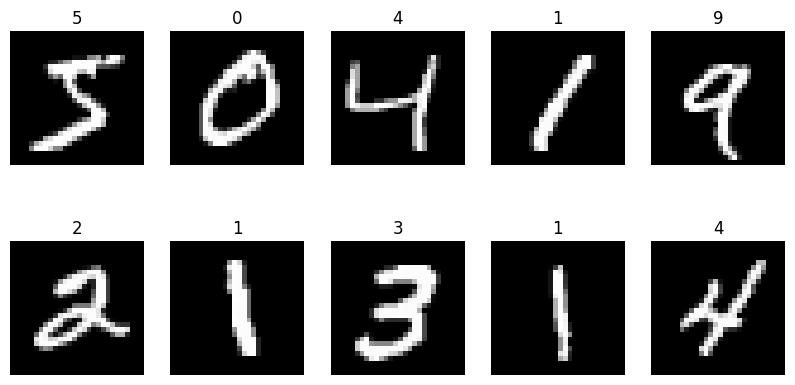

In [4]:
# Show sample images
plt.figure(figsize=(10, 5))

for i in range(10):

    plt.subplot(2, 5, i + 1)

    plt.imshow(
        X_train[i],
        cmap="gray"
    )

    plt.title(y_train[i])

    plt.axis("off")

plt.show()

In [5]:
# Normalize data
X_train = X_train / 255.0

X_test = X_test / 255.0

Pixel values:

0 → 255

become:

0 → 1

which improves learning.

In [6]:
# Reshape image
X_train = X_train.reshape(
    -1,
    28,
    28,
    1
)

X_test = X_test.reshape(
    -1,
    28,
    28,
    1
)

CNN expects:

(height, width, channels)

In [7]:
# Build CNN model

model = Sequential()

model.add(
    Conv2D(
        32,
        (3, 3),
        activation="relu",
        input_shape=(28, 28, 1)
    )
)

model.add(
    MaxPooling2D((2, 2))
)

model.add(
    Conv2D(
        64,
        (3, 3),
        activation="relu"
    )
)

model.add(
    MaxPooling2D((2, 2))
)

model.add(
    Flatten()
)

model.add(
    Dense(
        128,
        activation="relu"
    )
)

model.add(
    Dropout(0.5)
)

model.add(
    Dense(
        10,
        activation="softmax"
    )
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
# Compile model
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [9]:
# Train model
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    validation_data=(X_test, y_test)
)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - accuracy: 0.9398 - loss: 0.2000 - val_accuracy: 0.9789 - val_loss: 0.0649
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9763 - loss: 0.0778 - val_accuracy: 0.9884 - val_loss: 0.0328
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9835 - loss: 0.0563 - val_accuracy: 0.9900 - val_loss: 0.0311
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9865 - loss: 0.0444 - val_accuracy: 0.9918 - val_loss: 0.0233
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9885 - loss: 0.0386 - val_accuracy: 0.9926 - val_loss: 0.0212


In [10]:
# Evaluate model
loss, accuracy = model.evaluate(
    X_test,
    y_test
)

print("Accuracy:", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9926 - loss: 0.0212
Accuracy: 0.9926000237464905


In [11]:
# Plot accuracy

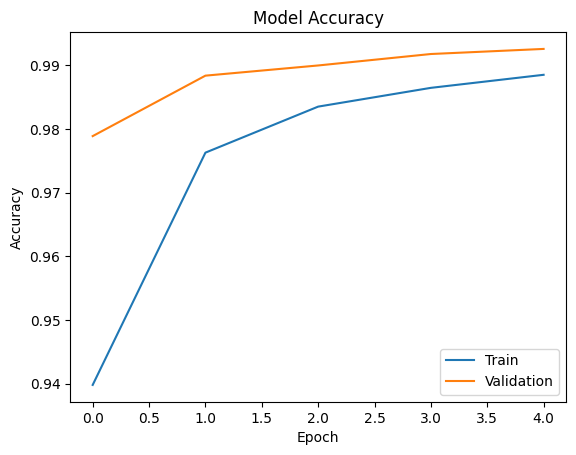

In [12]:
plt.plot(
    history.history["accuracy"]
)

plt.plot(
    history.history["val_accuracy"]
)

plt.title(
    "Model Accuracy"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Accuracy"
)

plt.legend(
    [
        "Train",
        "Validation"
    ]
)

plt.show()

In [13]:
# Predict one digit
prediction = model.predict(
    X_test[:1]
)

digit = np.argmax(
    prediction
)

print(
    "Predicted digit:",
    digit
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 462ms/step
Predicted digit: 7
